In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 34.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
data=pd.read_csv("/content/city_day.csv")

data.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
clean_df = data.dropna(subset=['PM2.5', 'NO2', 'O3']).reset_index(drop=True)

In [6]:
print(f"Original rows: {len(data)} | Cleaned rows: {len(clean_df)}")
print(clean_df[['City', 'Date', 'PM2.5', 'NO2', 'O3']].head())

Original rows: 29531 | Cleaned rows: 23948
        City        Date   PM2.5    NO2      O3
0  Ahmedabad  2015-01-28   73.24  21.11   62.42
1  Ahmedabad  2015-01-29   83.13  28.71   59.76
2  Ahmedabad  2015-01-30   79.84  28.68   97.07
3  Ahmedabad  2015-01-31   94.52  32.66  111.33
4  Ahmedabad  2015-02-01  135.99  42.08  102.70


In [7]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [8]:
pm25=ctrl.Antecedent(np.arange(0,501,1), 'PM25')
no2=ctrl.Antecedent(np.arange(0,401,1), 'NO2')
o3=ctrl.Antecedent(np.arange(0,401,1), 'O3')

hazard=ctrl.Consequent(np.arange(0,101,1),'Hazard')


In [9]:
pm25['Good']=fuzz.trapmf(pm25.universe,[0,0,30,60])
pm25['Moderate']=fuzz.trimf(pm25.universe,[30,60,120])
pm25['Unhealthy']=fuzz.trapmf(pm25.universe,[90,120,500,500])

In [10]:
no2['Low']      = fuzz.trapmf(no2.universe, [0, 0, 40, 80])
no2['Moderate'] = fuzz.trimf(no2.universe, [40, 80, 180])
no2['High']     = fuzz.trapmf(no2.universe, [100, 180, 400, 400])

In [11]:
o3['Low']      = fuzz.trapmf(o3.universe, [0, 0, 50, 100])
o3['Moderate'] = fuzz.trimf(o3.universe, [50, 100, 168])
o3['High']     = fuzz.trapmf(o3.universe, [100, 168, 400, 400])

In [12]:
hazard['Safe']     = fuzz.trimf(hazard.universe, [0, 0, 30])
hazard['Moderate'] = fuzz.trimf(hazard.universe, [20, 50, 70])
hazard['High']     = fuzz.trimf(hazard.universe, [60, 80, 100])
hazard['Critical'] = fuzz.trapmf(hazard.universe, [80, 90, 100, 100])

In [13]:
rule1 = ctrl.Rule(pm25['Good'] & no2['Low'] & o3['Low'], hazard['Safe'])
rule2 = ctrl.Rule(pm25['Moderate'] | no2['Moderate'] | o3['Moderate'], hazard['Moderate'])
rule3 = ctrl.Rule(pm25['Moderate'] & (no2['High'] | o3['High']), hazard['High'])
rule4 = ctrl.Rule(pm25['Unhealthy'] | no2['High'] | o3['High'], hazard['Critical'])

In [14]:
hazard_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
hazard_sim = ctrl.ControlSystemSimulation(hazard_ctrl)

In [15]:
first_row = clean_df.iloc[0]

In [16]:
hazard_sim.input['PM25'] = first_row['PM2.5']
hazard_sim.input['NO2']  = first_row['NO2']
hazard_sim.input['O3']   = first_row['O3']

In [17]:
hazard_sim.compute()

In [18]:
print("=" * 45)
print(f"City: {first_row['City']} | Date: {first_row['Date']}")
print("-" * 45)
print(f"Inputs  -> PM2.5: {first_row['PM2.5']} | NO2: {first_row['NO2']} | O3: {first_row['O3']}")
print(f"Output  -> Fuzzy Health Hazard Score: {hazard_sim.output['Hazard']:.2f} / 100")
print("=" * 45)

City: Ahmedabad | Date: 2015-01-28
---------------------------------------------
Inputs  -> PM2.5: 73.24 | NO2: 21.11 | O3: 62.42
Output  -> Fuzzy Health Hazard Score: 46.53 / 100


In [19]:
import matplotlib.pyplot as plt

In [20]:
def calculate_fuzzy_score(row):
    try:
        hazard_sim.input['PM25'] = row['PM2.5']
        hazard_sim.input['NO2']  = row['NO2']
        hazard_sim.input['O3']   = row['O3']
        hazard_sim.compute()
        return hazard_sim.output['Hazard']
    except Exception:
        return np.nan

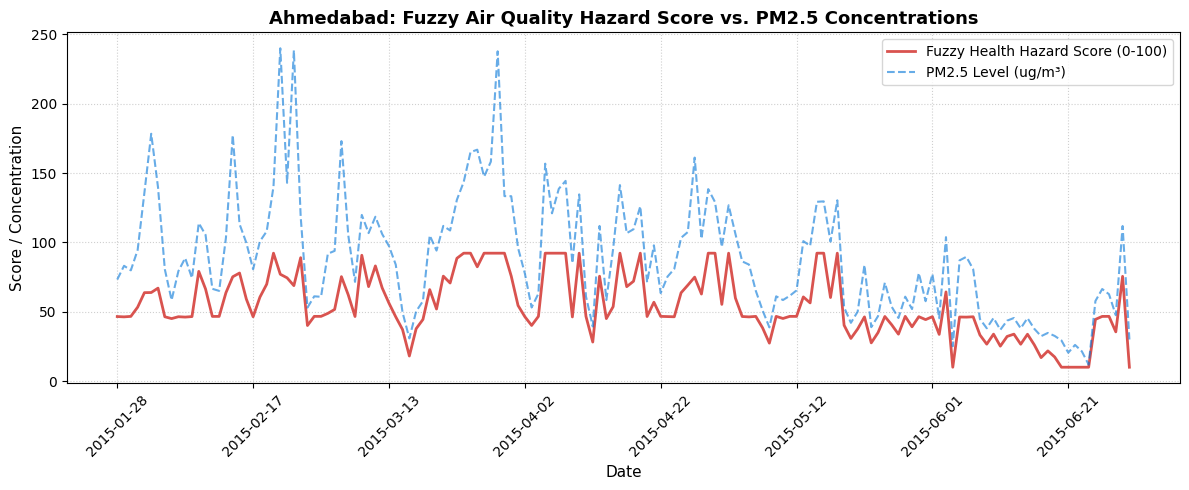

In [22]:
sample_df = clean_df[clean_df['City'] == 'Ahmedabad'].iloc[:150].copy()
sample_df['Fuzzy_Hazard'] = sample_df.apply(calculate_fuzzy_score, axis=1)
plt.figure(figsize=(12, 5))
plt.plot(sample_df['Date'], sample_df['Fuzzy_Hazard'], label='Fuzzy Health Hazard Score (0-100)', color='#d9534f', linewidth=2)
plt.plot(sample_df['Date'], sample_df['PM2.5'], label='PM2.5 Level (ug/m³)', color='#0275d8', alpha=0.6, linestyle='--')

plt.xticks(sample_df['Date'][::20], rotation=45) # Rotate x-axis dates for readability
plt.title('Ahmedabad: Fuzzy Air Quality Hazard Score vs. PM2.5 Concentrations', fontsize=13, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Score / Concentration', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

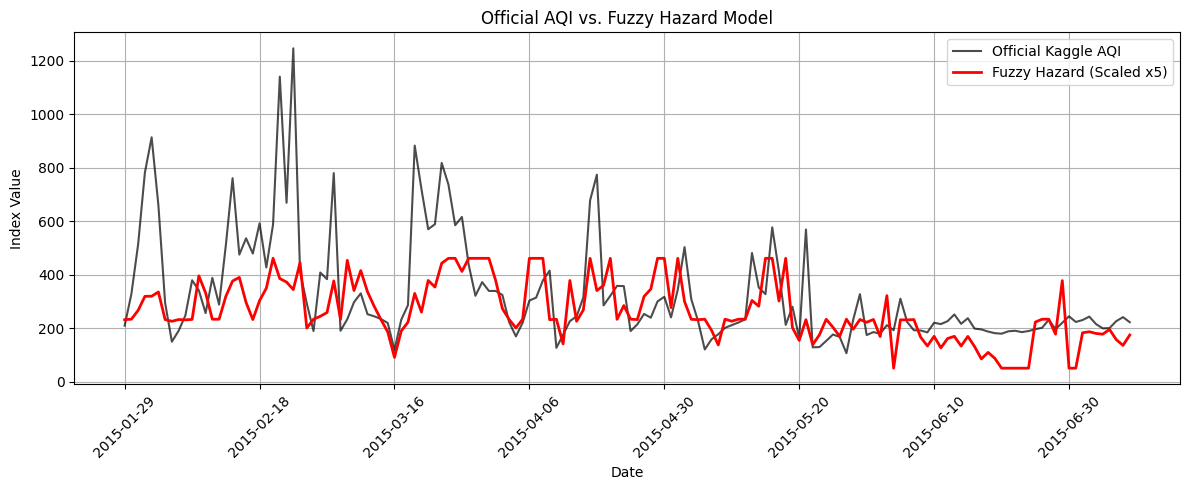

In [23]:
# Select rows where both official AQI and our Fuzzy Hazard Score exist
compare_df = clean_df[clean_df['City'] == 'Ahmedabad'].dropna(subset=['AQI']).iloc[:150].copy()
compare_df['Fuzzy_Hazard'] = compare_df.apply(calculate_fuzzy_score, axis=1)

# Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(compare_df['Date'], compare_df['AQI'], label='Official Kaggle AQI', color='black', alpha=0.7)
plt.plot(compare_df['Date'], compare_df['Fuzzy_Hazard'] * 5, label='Fuzzy Hazard (Scaled x5)', color='red', linewidth=2)
plt.xticks(compare_df['Date'][::20], rotation=45)
plt.title('Official AQI vs. Fuzzy Hazard Model')
plt.xlabel('Date')
plt.ylabel('Index Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

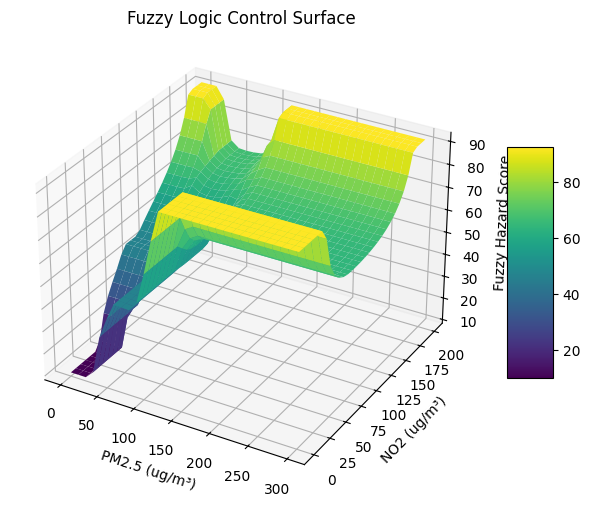

In [24]:
from mpl_toolkits.mplot3d import Axes3D

x_pm25, y_no2 = np.meshgrid(np.linspace(0, 300, 30), np.linspace(0, 200, 30))
z_hazard = np.zeros_like(x_pm25)

for i in range(30):
    for j in range(30):
        hazard_sim.input['PM25'] = x_pm25[i, j]
        hazard_sim.input['NO2'] = y_no2[i, j]
        hazard_sim.input['O3'] = 50  # Fixed baseline O3
        try:
            hazard_sim.compute()
            z_hazard[i, j] = hazard_sim.output['Hazard']
        except:
            z_hazard[i, j] = 0

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_pm25, y_no2, z_hazard, cmap='viridis', edgecolor='none')
ax.set_xlabel('PM2.5 (ug/m³)')
ax.set_ylabel('NO2 (ug/m³)')
ax.set_zlabel('Fuzzy Hazard Score')
ax.set_title('Fuzzy Logic Control Surface')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()